In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [53]:
df = pd.read_csv("06-study_hours_grades.csv")

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


Aşağıdaki gibi direkt tensor olarak alınıp manuel split işlemi de yapılabilir.

In [12]:
X = torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

Ama daha profesyonel ve randdom seçimleri sağlayabilmesi için öncelikle sklearn train_test_split ile ayırıp sonrasında her birini tensor olarak çevirmek daha mantıklı bence

In [55]:
X = df['study_hours'].values
y= df['grade'].values
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

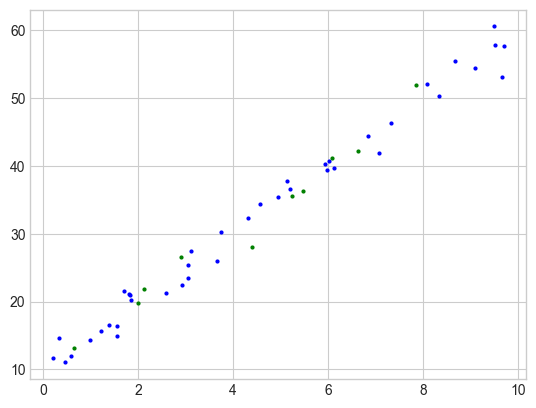

In [57]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.show()

In [58]:
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [59]:
torch.manual_seed(42)
model = LinearRegressionModel()
#model = torch.compile(model) # Daha büyük projelerde optimize etmek için kullanılıyormuş, sistemde c++ derleyicisi                                  gerekliymiş

In [60]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [61]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [62]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params= model.parameters(), lr= 0.01)

In [63]:
epochs = 120

for epoch in range(epochs):

    model.train()       # Train moduna almamız gerekiyor öncelikle

    # 1. Forward Pass
    y_pred = model(X_train)

    # 2. Loss calculation
    loss = loss_fn(y_pred, y_train)

    # 3. reset optimizer
    optimizer.zero_grad()

    # 4. backward prop
    loss.backward()

    # 5. optimize the weeights
    optimizer.step()

    # Test steps
    model.eval()                          # bu 2 satır ile test moduna geçmemiz gerekiyor,
    with torch.inference_mode():          # her epoch da test verisi de alabilmek için.
        test_pred = model(X_test)
        # 2. test loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 955.1275634765625 | Test loss: 169.29327392578125
Epoch: 5 | Train loss: 24.715885162353516 | Test loss: 17.459583282470703
Epoch: 10 | Train loss: 23.362302780151367 | Test loss: 16.305278778076172
Epoch: 15 | Train loss: 22.186405181884766 | Test loss: 15.496800422668457
Epoch: 20 | Train loss: 21.07950210571289 | Test loss: 14.739545822143555
Epoch: 25 | Train loss: 20.03754234313965 | Test loss: 14.027788162231445
Epoch: 30 | Train loss: 19.05671501159668 | Test loss: 13.358798027038574
Epoch: 35 | Train loss: 18.133434295654297 | Test loss: 12.7300386428833
Epoch: 40 | Train loss: 17.264331817626953 | Test loss: 12.139120101928711
Epoch: 45 | Train loss: 16.446210861206055 | Test loss: 11.583784103393555
Epoch: 50 | Train loss: 15.6760892868042 | Test loss: 11.061924934387207
Epoch: 55 | Train loss: 14.951159477233887 | Test loss: 10.571555137634277
Epoch: 60 | Train loss: 14.268760681152344 | Test loss: 10.110796928405762
Epoch: 65 | Train loss: 13.62639808

In [64]:
print(model.state_dict())

OrderedDict({'linear_layer.weight': tensor([[5.5894]]), 'linear_layer.bias': tensor([6.1039])})


In [66]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

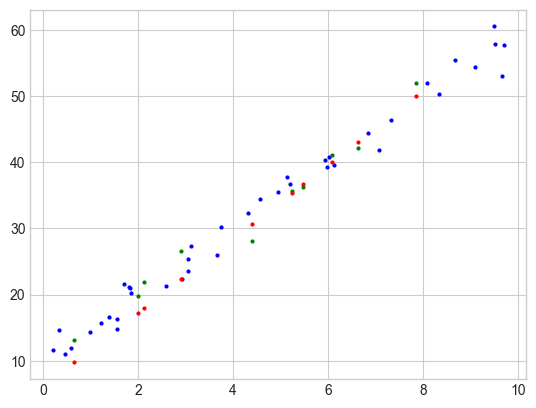

In [67]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()